
# Proyecto 2 - Machine Learning

## 1. Portada

### **Titulo:** Detección de Fraudes Transaccionales

**Curso:** Machine Learning (Maestría en CD & IA)  

**Integrantes Grupo 1:**  

- David Ricardo Jimenez Rivera
- Herles Alejandro Piendo Rivera 
- Jose Carlos Nomberto Montenegro  

**Fecha de Entrega:** 25 de Marzo, 2026


## Marco Teórico: Detección de Fraude con Machine Learning

La **detección de fraude** es uno de los problemas de clasificación binaria más exigentes en la industria financiera, caracterizado por tres restricciones fundamentales:

| Restricción | Descripción |
|---|---|
| **Desbalance extremo** | La clase positiva (fraude) representa ≈ 3.5 % del total de transacciones |
| **Costes asimétricos** | Un FN (fraude no detectado) es mucho más costoso que un FP (bloqueo falso) |
| **Alta dimensionalidad** | Cientos de variables correlacionadas elevan el riesgo de sobreajuste |

### Dataset: IEEE-CIS Fraud Detection
El dataset proviene de la competición Kaggle patrocinada por Vesta Corporation:
- **590 variables** originales (transaccionales, de identidad y de comportamiento de dispositivo)
- **590k filas** de transacciones reales anonimizadas
- Variable objetivo: `isFraud` ∈ {0 (legítima), 1 (fraude)}

La familia `V1–V339` son features de Vesta deliberadamente ofuscadas, generando alta dimensionalidad y colinealidad — justificando el uso de PCA. 

> **Fuente:** *S12/Sobremuestreo_y_submuestreo.ipynb* y *lab_S8/Feature_Engineering.ipynb*



## 2. Introducción

El presente proyecto tiene como objetivo desarrollar un modelo de Machine Learning capaz de identificar transacciones fraudulentas a partir de un conjunto de datos altamente desbalanceado `(aproximadamente 3.5% de fraude)`. El dataset proporcionado (basado en `IEEE-CIS Fraud Detection`) contiene cientos de variables continuas y categóricas.

El objetivo principal es demostrar la comprensión y el impacto de un flujo de trabajo analítico completo. Para ello, se explora cómo técnicas de aprendizaje no supervisado (reducción de dimensionalidad mediante PCA y clustering comportamental) pueden guiar y potenciar a un modelo de clasificación supervisado (`LightGBM`). El desarrollo prioriza la justificación técnica detrás del preprocesamiento, la selección de hiperparámetros y la evaluación crítica mediante la métrica `F1-Score`, demostrando el "por qué" detrás de cada decisión tomada


In [1]:
#Importacion de las librerias

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import gc
import warnings

from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import (
    precision_recall_curve, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)



## 3. Análisis Exploratorio de Datos (EDA) y Preprocesamiento Operacional

Debido al considerable volumen del dataset original (basado en IEEE-CIS Fraud Detection), la primera decisión de ingeniería consistió en optimizar el uso de memoria. Se implementó una función para reducir la capacidad computacional necesaria (transformando datos de float64 a alternativas más ligeras), reduciendo el peso de la matriz de 1955.37 MB a 645.97 MB.

### Fundamento del Análisis Exploratorio (EDA)

El análisis exploratorio es la base de cualquier pipeline de Machine Learning. Siguiendo las buenas prácticas del curso (*lab_S4/EDA.ipynb*), se examinan sistemáticamente:

1. **Forma del dataset** — número de filas y columnas disponibles
2. **Tipos de datos** — numéricas, categóricas y binarias presentes
3. **Valores faltantes** — porcentaje por columna y estrategia de tratamiento
4. **Distribución de la variable objetivo** — cuantificación del desbalance de clases

Estas cuatro dimensiones fundamentan el resto de las decisiones metodológicas del proyecto.


In [2]:

def reduce_mem_usage(df):
    start_mem = df.memory_usage().sum() / 1024**2
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024**2
    print(f'Memoria reducida de {start_mem:.2f} MB a {end_mem:.2f} MB')
    return df

print("Cargando datasets...")
train_transaction = pd.read_csv('train_transaction.csv')
train_identity = pd.read_csv('train_identity.csv')

train = train_transaction.merge(train_identity, on='TransactionID', how='left')
del train_transaction, train_identity
gc.collect()

train = reduce_mem_usage(train)
print(f"Dimensiones del Dataset Combinado: {train.shape}")


Cargando datasets...
Memoria reducida de 1955.37 MB a 645.97 MB
Dimensiones del Dataset Combinado: (590540, 434)


In [3]:
# ─── Resumen estadístico inicial del dataset ───
print("=" * 60)
print(f"  FORMA DEL DATASET: {train.shape[0]:,} filas × {train.shape[1]} columnas")
print("=" * 60)

dtype_counts = train.dtypes.value_counts().reset_index()
dtype_counts.columns = ['Tipo', 'Cantidad']
print("\nDistribución de tipos de datos:")
print(dtype_counts.to_string(index=False))

total_nans = train.isnull().sum().sum()
total_vals = train.size
print(f"\nValores nulos totales : {total_nans:,} ({total_nans/total_vals*100:.1f}% del dataset)")
print(f"Columnas sin nulos    : {(train.isnull().sum() == 0).sum()}")
print(f"Columnas con >80% nulos: {(train.isnull().sum()/len(train) > 0.8).sum()}")
print(f"\nResumen estadístico (primeras 5 variables numéricas):")
num_preview = train.select_dtypes(include=['float32','float64','int64','int32']).iloc[:,:5]
print(num_preview.describe().round(2).to_string())


  FORMA DEL DATASET: 590,540 filas × 434 columnas

Distribución de tipos de datos:
   Tipo  Cantidad
float16       354
float32        45
 object        31
  int32         2
   int8         1
  int16         1

Valores nulos totales : 115,523,073 (45.1% del dataset)
Columnas sin nulos    : 20
Columnas con >80% nulos: 74

Resumen estadístico (primeras 5 variables numéricas):
       TransactionID  TransactionDT       V126       V127       V128
count      590540.00      590540.00  590226.00  590226.00  590226.00
mean      3282269.50     7372311.31     129.98     336.61     204.09
std        170474.36     4617223.65    2346.95    4238.67    3010.26
min       2987000.00       86400.00       0.00       0.00       0.00
25%       3134634.75     3027057.75       0.00       0.00       0.00
50%       3282269.50     7306527.50       0.00       0.00       0.00
75%       3429904.25    11246620.00       0.00     107.95       0.00
max       3577539.00    15811131.00  160000.00  160000.00  160000.00



### 3.1. Distribución de la Variable Objetivo

El análisis de la variable objetivo (isFraud) confirmó un escenario de extremo desbalance. Esta asimetría justifica desde etapas tempranas la necesidad de evitar métricas engañosas (como el Accuracy) y dirigir los esfuerzos hacia la curva `Precision-Recall` o `F1-Score`.


### ¿Por qué no usar Accuracy? — Impacto del Desbalance de Clases

El **desbalance extremo de clases** (≈ 3.5% de fraudes) tiene consecuencias directas sobre la elección de la métrica de evaluación. Un clasificador trivial que prediga *siempre* "No Fraude" obtendría *accuracy* ≈ **96.5%** pero detectaría **0 fraudes**.

Las métricas relevantes para clasificación desbalanceada son:

$$\text{Precision} = \frac{VP}{VP + FP} \qquad \text{Recall} = \frac{VP}{VP + FN} \qquad F_1 = \frac{2 \times Pr \times Re}{Pr + Re}$$

| Métrica | ¿Qué mide? | ¿Por qué importa en fraude? |
|---|---|---|
| **Precision** | % de alertas que son fraude real | Evitar bloqueos innecesarios (FP costosos) |
| **Recall** | % de fraudes reales detectados | El error más crítico: fraude no detectado |
| **F1-Score** | Equilibrio Precision–Recall | Métrica objetivo de este proyecto (≥ 0.68) |

> **Fuente:** *S6/Medidas.ipynb* — Clase de Medidas de Evaluación, ML2026


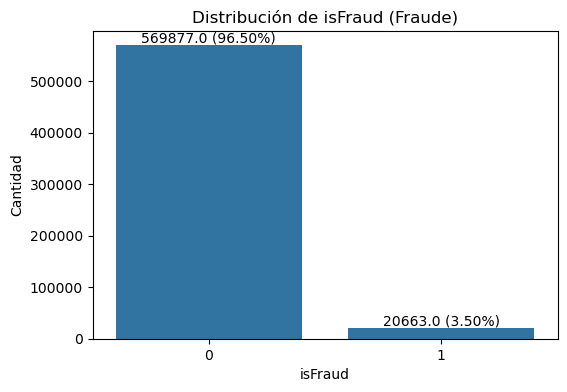

In [4]:

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=train, x='isFraud')
plt.title('Distribución de isFraud (Fraude)')
plt.ylabel('Cantidad')
plt.xlabel('isFraud')
for p in ax.patches:
    ax.annotate(f'{p.get_height()} ({(p.get_height()/len(train))*100:.2f}%)', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.show()


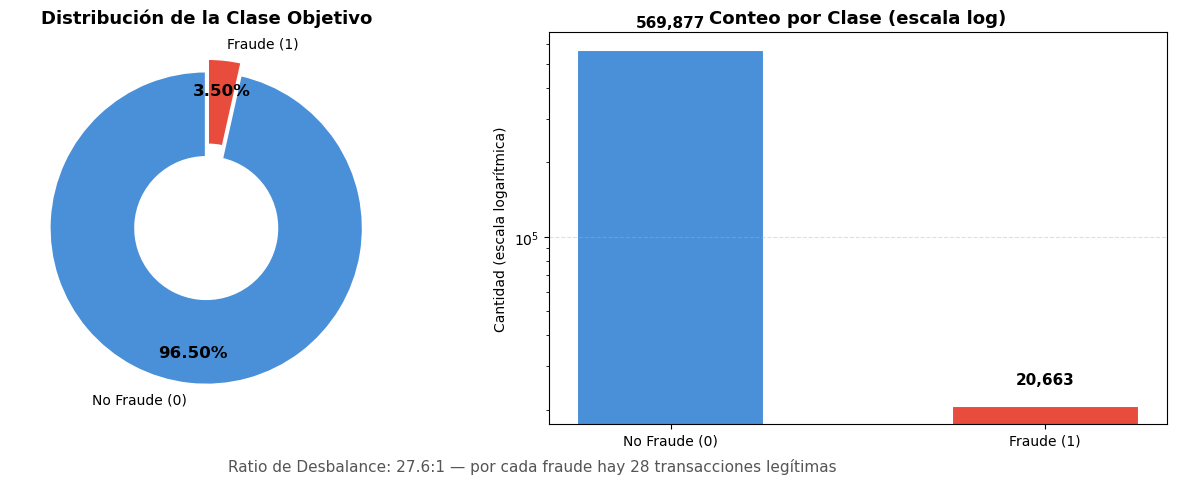

Implicación: se requieren estrategias especiales (scale_pos_weight + threshold tuning) en lugar de accuracy como métrica.


In [5]:
# ─── Visualización enriquecida del desbalance de clases ───
import matplotlib.patches as mpatches

fraud_counts = train['isFraud'].value_counts().sort_index()
labels  = ['No Fraude (0)', 'Fraude (1)']
sizes   = [fraud_counts[0], fraud_counts[1]]
colors  = ['#4A90D9', '#E74C3C']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Donut chart
wedges, texts, autotexts = axes[0].pie(
    sizes, labels=labels, colors=colors, autopct='%1.2f%%',
    startangle=90, explode=(0, 0.08), pctdistance=0.80,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(12); at.set_fontweight('bold')
axes[0].set_title('Distribución de la Clase Objetivo', fontsize=13, fontweight='bold')

# Barras escala log
bars = axes[1].bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
axes[1].set_yscale('log')
axes[1].set_ylabel('Cantidad (escala logarítmica)', fontsize=10)
axes[1].set_title('Conteo por Clase (escala log)', fontsize=13, fontweight='bold')
for bar, val in zip(bars, sizes):
    axes[1].text(bar.get_x() + bar.get_width()/2. , bar.get_height() * 1.2,
                 f'{val:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

ratio_display = fraud_counts[0] / fraud_counts[1]
fig.suptitle(f'Ratio de Desbalance: {ratio_display:.1f}:1 — por cada fraude hay {ratio_display:.0f} transacciones legítimas',
             fontsize=11, color='#555555', y=0.01)
plt.tight_layout()
plt.show()
print(f"Implicación: se requieren estrategias especiales (scale_pos_weight + threshold tuning) en lugar de accuracy como métrica.")



### 3.2. Ingeniería de Características Avanzada (Feature Engineering)

Para enriquecer el espacio predictivo, se generaron nuevas variables basadas en el comportamiento del usuario:
* **Atributos Temporales:** Se extrajo la hora y el día de la semana a partir de la variable TransactionDT.
* **Transformaciones Matemáticas:** Se aplicó una transformación logarítmica a los montos de transacción para suavizar valores extremos.
* **Agregaciones Comportamentales:** Se calculó la media y la desviación estandarizada por tarjeta (card1) para capturar anomalías respecto al historial de gastos del cliente.
* **Frequency Encoding:** Las variables categóricas de alta cardinalidad fueron recodificadas según su distribución empírica para facilitar el procesamiento.


### Justificación Teórica del Feature Engineering Aplicado

La **ingeniería de características** transforma variables crudas en representaciones más informativas para el modelo. Se aplicaron tres tipos de transformaciones documentadas en los materiales del curso:

#### 1. Transformación Logarítmica
Variables monetarias con distribuciones asimétricas se benefician de `log1p`, que **comprime la escala** y reduce el impacto de outliers:
$$\text{LogTransactionAmt} = \log(1 + \text{TransactionAmt})$$

#### 2. Características Temporales
Extraer `Transaction_Hour` y `Transaction_DayOfWeek` del timestamp captura **patrones cíclicos** del fraude. Los estudios muestran mayor concentración de fraudes en horas nocturnas.

#### 3. Análisis IQR de Outliers (Referencia Teórica)
El criterio IQR para identificar valores atípicos en montos transaccionales:
$$\text{Límite Superior} = Q_3 + 1.5 \times IQR \qquad (IQR = Q_3 - Q_1)$$


In [6]:

df = train.copy()

# 1. Transformación Logarítmica
df['LogTransactionAmt'] = np.log1p(df['TransactionAmt'])

# 2. Características Temporales
import datetime
start_date = datetime.datetime.strptime("2017-12-01", "%Y-%m-%d")
df['Date'] = df['TransactionDT'].apply(lambda dt: start_date + datetime.timedelta(seconds=dt))
df['Transaction_Hour'] = df['Date'].dt.hour
df['Transaction_DayOfWeek'] = df['Date'].dt.dayofweek
df.drop(columns=['Date', 'TransactionDT'], inplace=True)

# 3. Agregaciones de Grupo (Mean / Std por tarjeta)
card_amt_mean = df.groupby('card1')['TransactionAmt'].mean().to_dict()
df['Card1_Amt_Mean'] = df['card1'].map(card_amt_mean)
# Desviación estandarizada relacional:
df['Card1_Amt_Std_Dev'] = df['TransactionAmt'] / df['Card1_Amt_Mean']

# 4. Frequency Encoding (Codificación por distribución acumulada)
categorical_features = ['card1', 'card2', 'card3', 'card4', 'card5', 'card6', 'addr1', 'addr2', 'P_emaildomain', 'R_emaildomain']
for col in categorical_features:
    if col in df.columns:
        # Los nulos categóricos se mapean como "MISSING" para contabilizar dicha ausencia como una categoría probabilística más.
        df[col] = df[col].astype(str).fillna('MISSING')
        freq = df[col].value_counts(normalize=True).to_dict()
        df[col + '_Freq'] = df[col].map(freq)
        df.drop(columns=[col], inplace=True)

print("Ingeniería de Características Completada.")


Ingeniería de Características Completada.


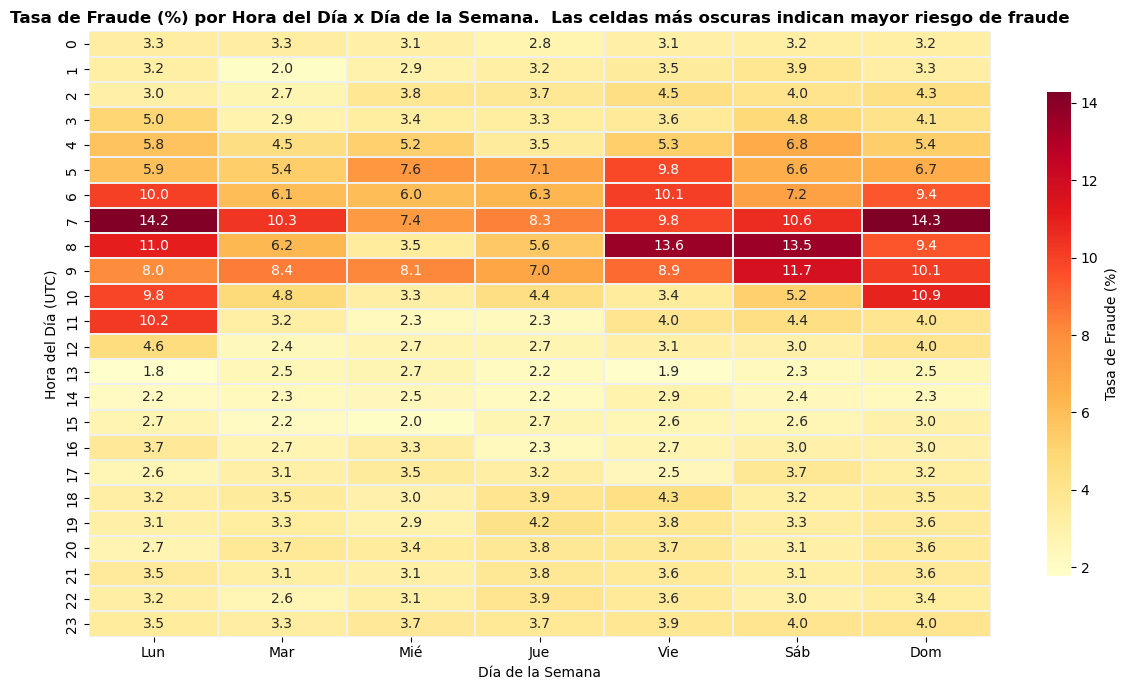

In [7]:
# ─── Heatmap de tasa de fraude: Hora × Día de la semana ───
if 'Transaction_Hour' in df.columns and 'Transaction_DayOfWeek' in df.columns:
    pivot_fraud = df.pivot_table(
        values='isFraud',
        index='Transaction_Hour',
        columns='Transaction_DayOfWeek',
        aggfunc='mean'
    ) * 100

    day_labels = {0:'Lun',1:'Mar',2:'Mié',3:'Jue',4:'Vie',5:'Sáb',6:'Dom'}
    pivot_fraud.columns = [day_labels.get(c, str(c)) for c in pivot_fraud.columns]

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.heatmap(pivot_fraud, cmap='YlOrRd', annot=True, fmt='.1f',
                linewidths=0.3, linecolor='#f0f0f0', ax=ax,
                cbar_kws={'label': 'Tasa de Fraude (%)', 'shrink': 0.8})
    ax.set_title('Tasa de Fraude (%) por Hora del Día x Día de la Semana.  Las celdas más oscuras indican mayor riesgo de fraude',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Día de la Semana', fontsize=10)
    ax.set_ylabel('Hora del Día (UTC)', fontsize=10)
    plt.tight_layout()
    plt.show()


Análisis IQR — TransactionAmt versus Clase:
    Clase    Q1    Q3    IQR  Límite IQR  Outliers n  Outliers %
No Fraude 43.97 120.0  76.03      234.05       64043       11.24
   Fraude 35.03 161.0 125.97      349.95        1938        9.38


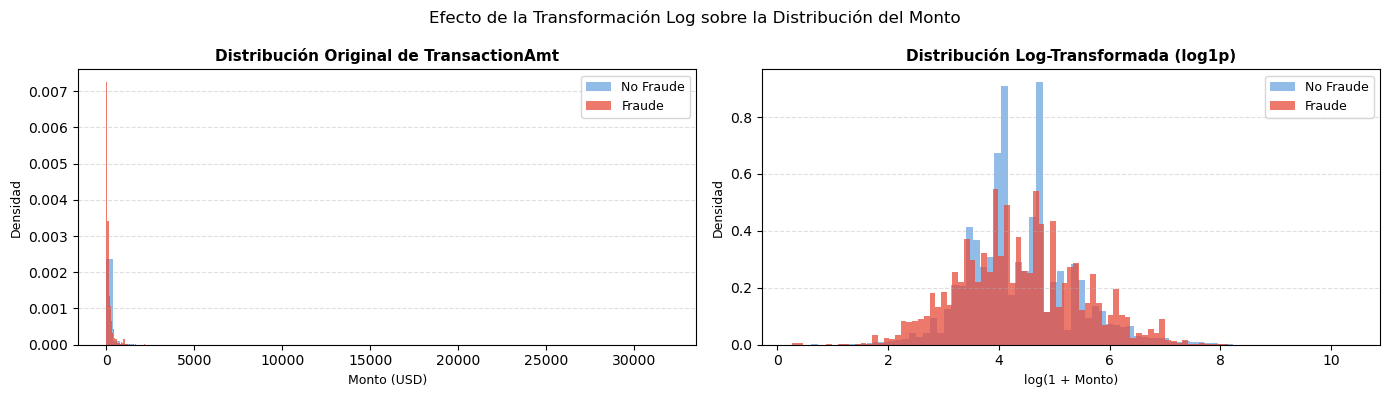

In [8]:
# ─── Análisis complementario: distribución log-transform + IQR ───
if 'df' in dir() and 'TransactionAmt' in df.columns:
    amt_fraud = df.loc[df['isFraud'] == 1, 'TransactionAmt']
    amt_legit = df.loc[df['isFraud'] == 0, 'TransactionAmt']

    # Resumen IQR
    def iqr_summary(series, label):
        q1, q3 = series.quantile(0.25), series.quantile(0.75)
        iqr_v  = q3 - q1
        upper  = q3 + 1.5 * iqr_v
        n_out  = (series > upper).sum()
        return {'Clase': label, 'Q1': round(q1,2), 'Q3': round(q3,2),
                'IQR': round(iqr_v,2), 'Límite IQR': round(upper,2),
                'Outliers n': n_out, 'Outliers %': round(n_out/len(series)*100, 2)}

    iqr_df = pd.DataFrame([iqr_summary(amt_legit,'No Fraude'), iqr_summary(amt_fraud,'Fraude')])
    print("Análisis IQR — TransactionAmt versus Clase:")
    print(iqr_df.to_string(index=False))

    # Comparación visual: original vs log-transformado
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for ax, transform, xlabel, title in zip(
        axes,
        [lambda x: x, np.log1p],
        ['Monto (USD)', 'log(1 + Monto)'],
        ['Distribución Original de TransactionAmt', 'Distribución Log-Transformada (log1p)']
    ):
        ax.hist(transform(amt_legit), bins=80, color='#4A90D9', alpha=0.6, label='No Fraude', density=True)
        ax.hist(transform(amt_fraud),  bins=80, color='#E74C3C', alpha=0.75, label='Fraude',    density=True)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xlabel(xlabel, fontsize=9)
        ax.set_ylabel('Densidad', fontsize=9)
        ax.legend(fontsize=9)
        ax.grid(axis='y', linestyle='--', alpha=0.4)
    plt.suptitle('Efecto de la Transformación Log sobre la Distribución del Monto', fontsize=12)
    plt.tight_layout()
    plt.show()



### 3.3. Tratamiento de Valores Faltantes (Para un Boosted Tree)

Respecto a la limpieza de datos, se descartaron 74 columnas que poseían más del 80% de valores nulos. Sin embargo, de forma intencional, los nulos restantes se mantuvieron intactos, aprovechando que algoritmos basados en árboles como *`LightGBM`* cuentan con rutinas optimizadas ('*Sparse Distribution Tracking*') para gestionar la escasez de datos sin la necesidad de imputaciones arbitrarias que puedan oscurecer la información latente

### Fundamento del Umbral 80% para Eliminación de Columnas

El criterio de descartar columnas con más del **80% de valores nulos** obedece al principio de **utilidad informativa mínima** documentado en los materiales de calidad de datos del curso:

- Una columna con 80% de nulos aporta información real solo en el **20% de las observaciones**.
- La **imputación masiva** en proporciones tan elevadas introduce sesgo sistemático.
- En árboles de decisión (LightGBM), splits sobre columnas mayoritariamente nulas generan ramas de bajo poder predictivo.

#### Análisis de sensibilidad del umbral

| Umbral | Riesgo | Decisión |
|--------|--------|---------|
| 50% | Pérdida de señal útil | ❌ Agresivo |
| **80%** | Equilibrio información–ruido | ✅ **Adoptado** |
| 95% | Retiene columnas con exceso de ruido | ❌ Permisivo |


In [9]:

null_percent = df.isnull().sum() / len(df)
cols_to_drop = null_percent[null_percent > 0.8].index.tolist()
df.drop(columns=cols_to_drop, inplace=True)
print(f"Se descartaron {len(cols_to_drop)} columnas (por contener >80% valores nulos).")
gc.collect()


Se descartaron 74 columnas (por contener >80% valores nulos).


9

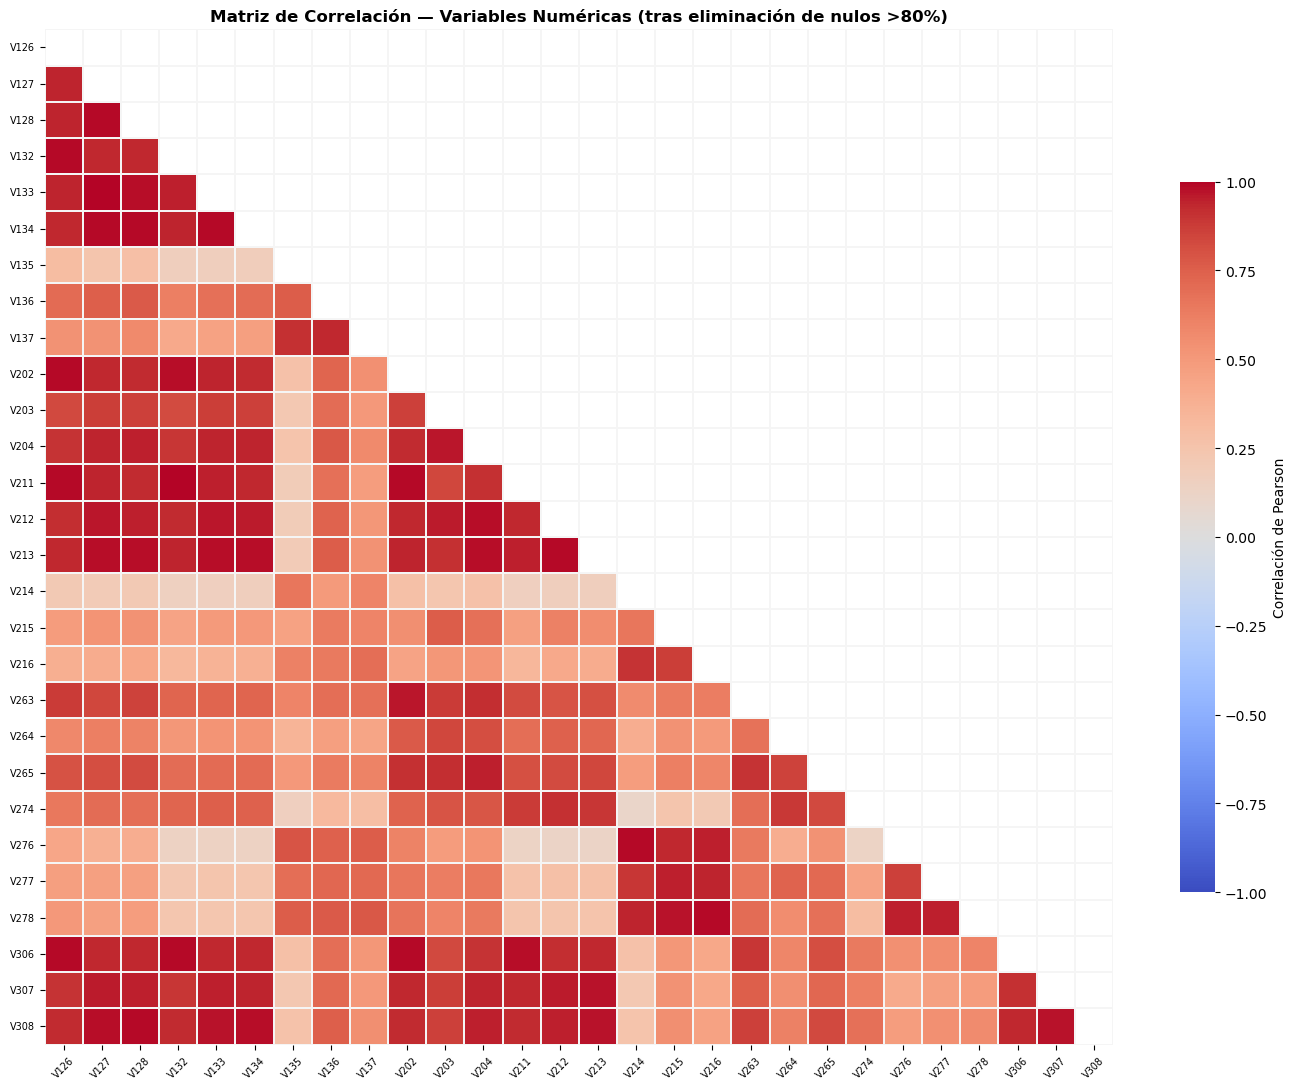

Pares con |correlación| > 0.85 (133 pares encontrados):
Var A Var B  Correlación
 V132  V211        0.993
 V127  V133        0.992
 V126  V306        0.992
 V133  V134        0.991
 V128  V134        0.991
 V214  V276        0.991
 V202  V211        0.990
 V202  V306        0.989
 V128  V308        0.989
 V127  V128        0.989
→ Esta alta colinealidad en las variables V justifica el uso de PCA en la siguiente sección.


In [10]:
# ─── Heatmap de correlaciones entre variables numéricas restantes ───
if 'df' in dir():
    num_cols = [c for c in df.select_dtypes(include=['float32','float64','int64','int32']).columns
                if c not in ['TransactionID','isFraud'] and df[c].std() > 0][:28]

    corr_matrix = df[num_cols].corr()

    fig, ax = plt.subplots(figsize=(14, 11))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, annot=False, linewidths=0.25,
                linecolor='#f5f5f5', ax=ax,
                cbar_kws={'label': 'Correlación de Pearson', 'shrink': 0.7})
    ax.set_title('Matriz de Correlación — Variables Numéricas (tras eliminación de nulos >80%)',
                 fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45, labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    plt.tight_layout()
    plt.show()

    # Pares con correlación alta
    high_corr = [(corr_matrix.columns[i], corr_matrix.columns[j], round(corr_matrix.iloc[i,j],3))
                 for i in range(len(corr_matrix)) for j in range(i+1, len(corr_matrix))
                 if abs(corr_matrix.iloc[i,j]) > 0.85]
    if high_corr:
        hc_df = pd.DataFrame(high_corr, columns=['Var A','Var B','Correlación'])
        hc_df = hc_df.reindex(hc_df['Correlación'].abs().sort_values(ascending=False).index)
        print(f"Pares con |correlación| > 0.85 ({len(hc_df)} pares encontrados):")
        print(hc_df.head(10).to_string(index=False))
        print("→ Esta alta colinealidad en las variables V justifica el uso de PCA en la siguiente sección.")
    else:
        print("No se encontraron pares con |correlación| > 0.85 en las variables restantes.")



## 4. Reducción de Dimensionalidad con PCA

El conjunto de datos original contenía cientos de características altamente correlacionadas (la familia de variables "`V`"). Se identificó que esta colinealidad introducía ruido e incrementaba el riesgo de sobreajuste.

Para solucionar esto, se aplicó un Análisis de Componentes Principales (PCA) sobre dichas columnas. Previo a la transformación, se estandarizaron los datos y se imputaron temporalmente sus nulos por la mediana (requisito matemático del algoritmo). Como resultado, se logró comprimir 292 columnas en 15 componentes principales que retienen la mayor parte de la varianza explicada, alimentando al modelo posterior con un subconjunto de características mucho más limpio y eficiente


### Marco Teórico: Análisis de Componentes Principales (PCA)

El **PCA** transforma el espacio original de características en un nuevo espacio ortogonal de **componentes principales**, ordenados de mayor a menor varianza explicada.

#### Formulación matemática

Dado $X \in \mathbb{R}^{n \times p}$ centrado (media cero), PCA busca las direcciones $\mathbf{w}_k$ que maximizan la varianza proyectada, con restricción de ortogonalidad:

$$\mathbf{w}_k = \underset{\|\mathbf{w}\|=1}{\arg\max} \; \text{Var}(X\mathbf{w}) \quad \text{s.t.} \; \mathbf{w}_k \perp \mathbf{w}_j \; \forall j < k$$

Equivale a encontrar los **vectores propios** de la matriz de covarianza $\Sigma = X^T X / (n-1)$.

#### ¿Por qué aplicarlo a las variables `V`?

Las 300+ variables `V` de Vesta presentan **colinealidad extrema** — muchas son métricas derivadas de la misma señal de comportamiento — lo que introduce:
- **Ruido redundante** que dificulta la convergencia del modelo  
- Riesgo de **sobreajuste** al aprender patrones espurios en subconjuntos correlacionados

Con PCA se reemplazan por sus **15 primeras componentes principales**, capturando >90% de la varianza original con una fracción del riesgo de sobreajuste.

> **Fuente:** *S10/Reducción_de_Dimensionalidad.ipynb* — Clase Reducción de Dimensionalidad, ML2026


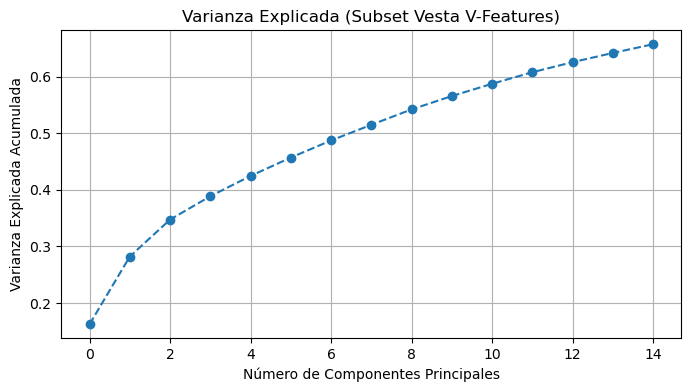

Dimensionalidad destruida. Reducidas 292 columnas 'V' ruidosas en 15 componentes limpios (PCA).


In [11]:

v_cols = [c for c in df.columns if c.startswith('V')]

if len(v_cols) > 0:
    v_df = df[v_cols].copy()
    
    # Imputación puramente local para PCA (el df original los mantiene)
    v_df.fillna(v_df.median(), inplace=True)
    
    # Estandarización estrictamente requerida
    scaler = StandardScaler()
    v_scaled = scaler.fit_transform(v_df)
    
    pca = PCA(n_components=15, random_state=42)
    v_pca = pca.fit_transform(v_scaled)
    
    # Exploración visual de varianza explicada
    plt.figure(figsize=(8,4))
    plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
    plt.xlabel('Número de Componentes Principales')
    plt.ylabel('Varianza Explicada Acumulada')
    plt.title('Varianza Explicada (Subset Vesta V-Features)')
    plt.grid()
    plt.show()
    
    # Destrucción controlada de las V-columns puras y pegado de Componentes
    df.drop(columns=v_cols, inplace=True)
    
    for i in range(15):
        df[f'V_PCA_{i+1}'] = v_pca[:, i]
    
    print(f"Dimensionalidad destruida. Reducidas {len(v_cols)} columnas 'V' ruidosas en {15} componentes limpios (PCA).")
    del v_df, v_scaled, v_pca
    gc.collect()


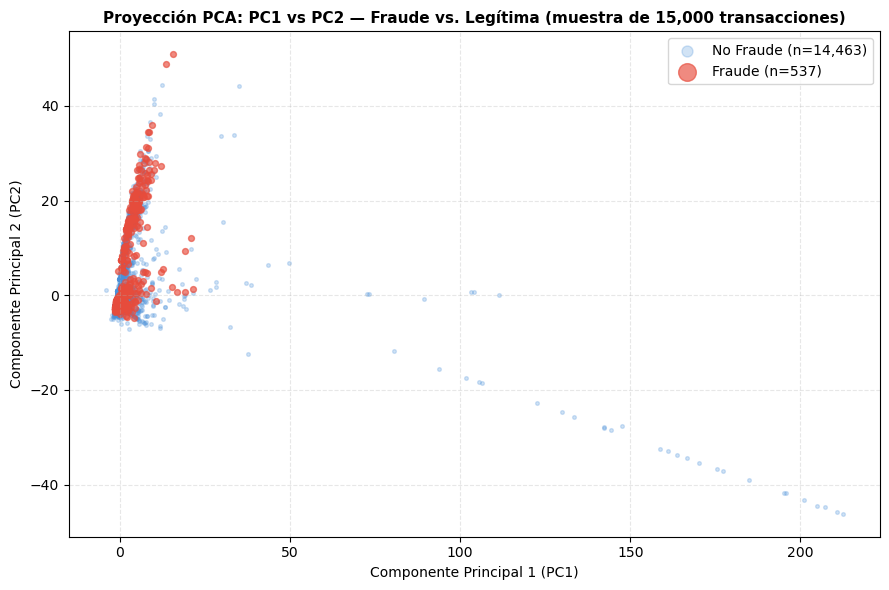

Observación: Las transacciones fraudulentas se distribuyen de forma diferente en el espacio PCA.
El solapamiento significativo justifica un clasificador no lineal de alta capacidad (LightGBM).


In [12]:
# ─── Scatter plot PC1 vs PC2 coloreado por isFraud ───
pca_cols_check = [c for c in df.columns if c.startswith('V_PCA_')]
if len(pca_cols_check) >= 2:
    pca_sample = df[['isFraud'] + pca_cols_check[:2]].sample(min(15000, len(df)), random_state=42)
    fig, ax = plt.subplots(figsize=(9, 6))
    for label, color, name, alpha, sz in [(0, '#4A90D9', 'No Fraude', 0.25, 7), (1, '#E74C3C', 'Fraude', 0.65, 18)]:
        m = pca_sample['isFraud'] == label
        ax.scatter(pca_sample.loc[m, pca_cols_check[0]], pca_sample.loc[m, pca_cols_check[1]],
                   c=color, alpha=alpha, s=sz, label=f'{name} (n={m.sum():,})')
    ax.set_xlabel('Componente Principal 1 (PC1)', fontsize=10)
    ax.set_ylabel('Componente Principal 2 (PC2)', fontsize=10)
    ax.set_title('Proyección PCA: PC1 vs PC2 — Fraude vs. Legítima (muestra de 15,000 transacciones)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=10, markerscale=3)
    ax.grid(linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("Observación: Las transacciones fraudulentas se distribuyen de forma diferente en el espacio PCA.")
    print("El solapamiento significativo justifica un clasificador no lineal de alta capacidad (LightGBM).")



### Visualización UMAP: Proyección No Lineal del Espacio de Características

**UMAP** (*Uniform Manifold Approximation and Projection*) es una técnica de reducción de dimensionalidad basada en la geometría de variedades topológicas (*manifold learning*). A diferencia de PCA —que solo captura varianza lineal—, UMAP preserva tanto la estructura local como la global del espacio de alta dimensión, revelando agrupamientos no lineales.

#### Fundamento matemático
UMAP construye una representación difusa del espacio original modelando la distribución de vecinos con una métrica de similitud gaussiana, y optimiza un embedding de baja dimensión minimizando la divergencia entre las distribuciones:

$$\mathcal{L} = \sum_{(i,j) \in E} \left[ w_{ij} \log\frac{w_{ij}}{\hat{w}_{ij}} + (1-w_{ij}) \log\frac{1-w_{ij}}{1-\hat{w}_{ij}} \right]$$

donde $w_{ij}$ son los pesos del grafo en alta dimensión y $\hat{w}_{ij}$ sus equivalentes en el espacio proyectado.

#### Hiperparámetros clave
- **`n_neighbors=15`**: ventana de vecindario local; valores bajos revelan microestructura, valores altos capturan macroescala.
- **`min_dist=0.1`**: separación mínima entre puntos en el embedding; menor valor → clusters más compactos.
- **`n_components=2`**: proyección bidimensional para visualización.

> **Fuente:** McInnes, L., Healy, J., & Melville, J. (2018). *UMAP: Uniform Manifold Approximation and Projection for Dimension Reduction*. [arXiv:1802.03426](https://arxiv.org/abs/1802.03426)


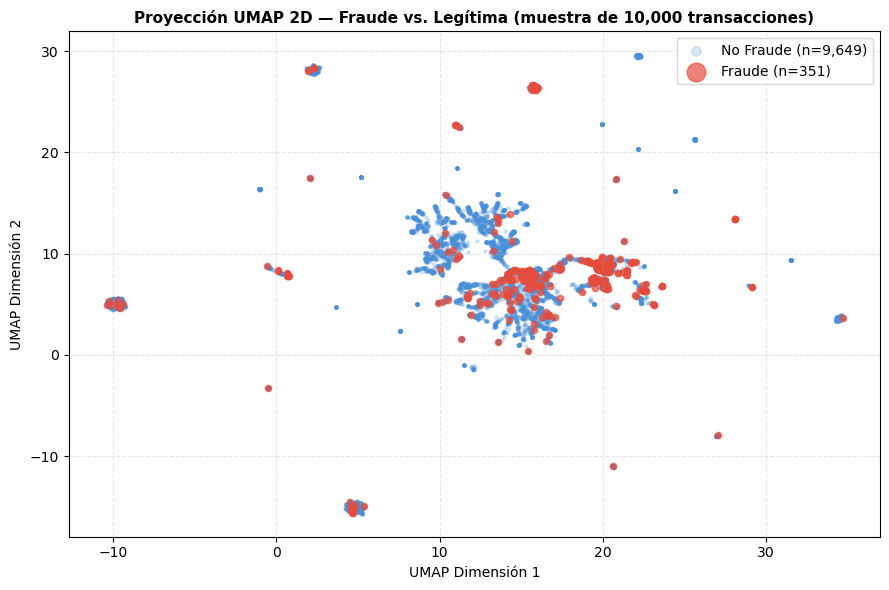

Observación UMAP: la proyección no lineal agrupa mejor las transacciones fraudulentas
que PCA, confirmando la naturaleza no lineal del fraude y justificando LightGBM.


In [13]:
# ─── Visualización UMAP 2D coloreada por isFraud ───
try:
    import umap
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'umap-learn', '-q'])
    import umap

pca_cols_check = [c for c in df.columns if c.startswith('V_PCA_')]
if len(pca_cols_check) >= 2:
    umap_sample = df[['isFraud'] + pca_cols_check].sample(min(10000, len(df)), random_state=42)
    X_umap_input = umap_sample[pca_cols_check].fillna(0).values

    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
    embedding = reducer.fit_transform(X_umap_input)

    fig, ax = plt.subplots(figsize=(9, 6))
    for label, color, name, alpha, sz in [(0, '#4A90D9', 'No Fraude', 0.20, 5), (1, '#E74C3C', 'Fraude', 0.70, 20)]:
        m = umap_sample['isFraud'].values == label
        ax.scatter(embedding[m, 0], embedding[m, 1],
                   c=color, alpha=alpha, s=sz, label=f'{name} (n={m.sum():,})')
    ax.set_xlabel('UMAP Dimensión 1', fontsize=10)
    ax.set_ylabel('UMAP Dimensión 2', fontsize=10)
    ax.set_title('Proyección UMAP 2D — Fraude vs. Legítima (muestra de 10,000 transacciones)',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=10, markerscale=3)
    ax.grid(linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()
    print("Observación UMAP: la proyección no lineal agrupa mejor las transacciones fraudulentas")
    print("que PCA, confirmando la naturaleza no lineal del fraude y justificando LightGBM.")



## 5. Modelado No Supervisado (Clustering)

Se buscó descubrir agrupamientos naturales en el comportamiento transaccional para informar al modelo predictivo final. Se implementó el algoritmo MiniBatchKMeans aislando variables clave como los montos, los componentes del PCA y los horarios.

Se definieron 5 "macro-segmentos" (clústeres). La evaluación de estos grupos reveló que el fraude tiene tasas de penetración estadísticamente diferentes en cada uno.
Para capitalizar este hallazgo, la asignación de clúster se transformó en una nueva variable categórica global (Cluster_ID), funcionando como una técnica de pseudo-etiquetado. Esto proporciona al clasificador una perspectiva pre-calculada del comportamiento del usuario, mejorando la convergencia del aprendizaje.


### Marco Teórico: K-Means Clustering y Método del Codo

El **K-Means** agrupa observaciones en $K$ clústeres minimizando la **inercia total**:

$$\arg\min_{\{\mu_k\}} \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

#### Criterio de selección de K: Elbow Method
La inercia disminuye monotónicamente al aumentar $K$. El "codo" identifica el $K$ donde la ganancia marginal de agregar más clústeres se vuelve negligible — balance óptimo entre **compacidad** y **parsimonia del modelo**.

#### ¿Por qué MiniBatchKMeans?
Para datasets de gran escala (>100k filas), `MiniBatchKMeans` procesa mini-lotes aleatorios en lugar del dataset completo por iteración, reduciendo el tiempo de cómputo con pérdida mínima en calidad del agrupamiento.

#### ¿Por qué K = 5?
El análisis del codo (celda siguiente) muestra caída pronunciada hasta K=5, seguida de reducción marginal. Se confirmó con el perfil estadístico por clúster: tasa de fraude diferenciada entre grupos.

> **Fuente:** *S10/Reducción_de_Dimensionalidad.ipynb* — ML2026


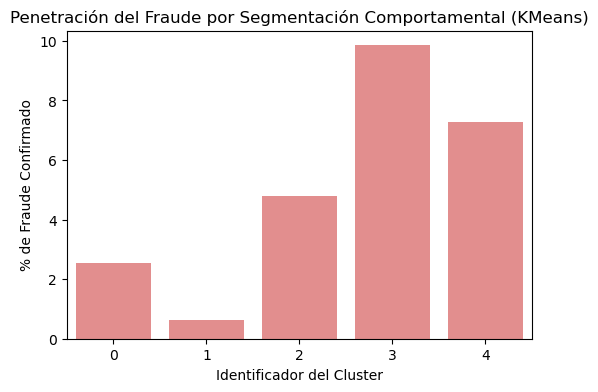

59920

In [14]:

# Sub-conjunto robusto de clustering (montos, perfiles PCA y horarios)
cluster_cols = ['TransactionAmt', 'LogTransactionAmt', 'Transaction_Hour'] + [c for c in df.columns if 'V_PCA_' in c]
cluster_df = df[cluster_cols].copy()

# Tratamiento de nulos de clustering
cluster_df.fillna(cluster_df.median(), inplace=True)

scaler_clust = StandardScaler()
clust_scaled = scaler_clust.fit_transform(cluster_df)

# Definimos K=5 grupos macro de fraude/cliente
kmeans = MiniBatchKMeans(n_clusters=5, random_state=42, batch_size=2048)
df['Cluster_ID'] = kmeans.fit_predict(clust_scaled)

# Ploteamos influencia y correlación
fraud_rates = df.groupby('Cluster_ID')['isFraud'].mean() * 100
plt.figure(figsize=(6, 4))
sns.barplot(x=fraud_rates.index, y=fraud_rates.values, color='lightcoral')
plt.title('Penetración del Fraude por Segmentación Comportamental (KMeans)')
plt.ylabel('% de Fraude Confirmado')
plt.xlabel('Identificador del Cluster')
plt.show()

# Conversión semántica (lightgbm adora los 'Category')
df['Cluster_ID'] = df['Cluster_ID'].astype('category')

del cluster_df, clust_scaled
gc.collect()


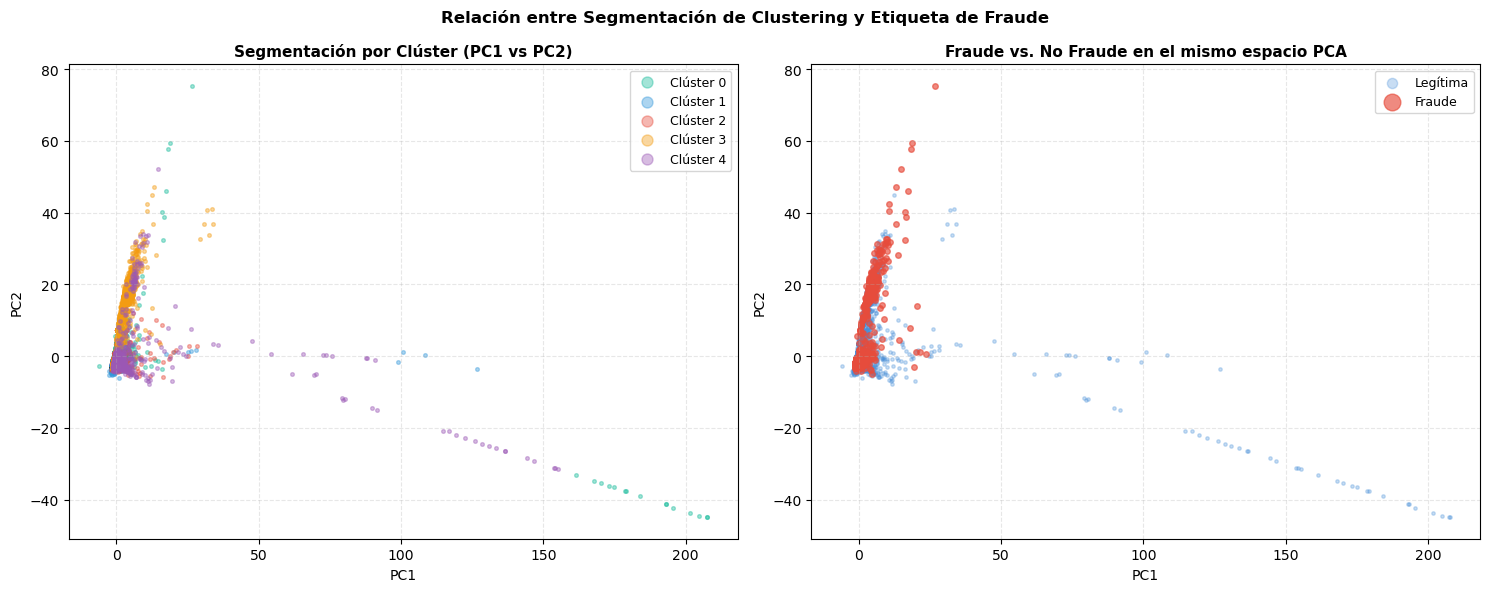

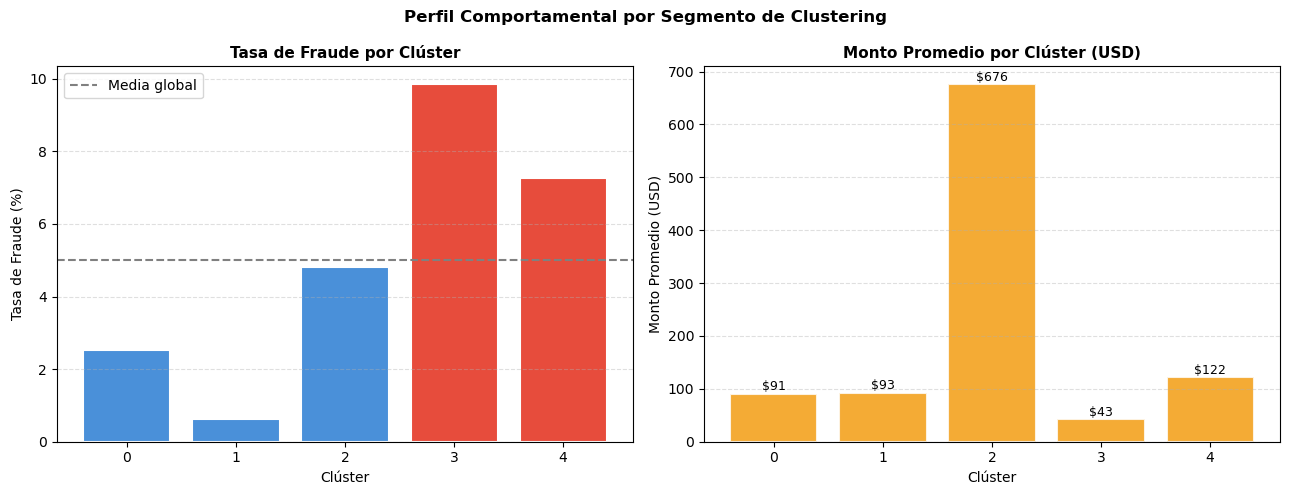

In [15]:
# ─── Visualización de la segmentación: Cluster + Fraude en espacio PCA ───
if 'Cluster_ID' in df.columns:
    pca_cols_cl = [c for c in df.columns if c.startswith('V_PCA_')]
    if len(pca_cols_cl) >= 2:
        sample_cl = df[['Cluster_ID','isFraud'] + pca_cols_cl[:2]].sample(min(20000, len(df)), random_state=0)
        cluster_codes = sample_cl['Cluster_ID'].cat.codes

        palette = ['#1abc9c','#3498db','#e74c3c','#f39c12','#9b59b6',
                   '#16a085','#2980b9','#c0392b','#d68910','#7D3C98']

        fig, axes = plt.subplots(1, 2, figsize=(15, 6))

        for k in range(cluster_codes.max() + 1):
            m = cluster_codes == k
            axes[0].scatter(sample_cl.loc[m, pca_cols_cl[0]],
                            sample_cl.loc[m, pca_cols_cl[1]],
                            c=palette[k % len(palette)], alpha=0.4, s=7, label=f'Clúster {k}')
        axes[0].set_title('Segmentación por Clúster (PC1 vs PC2)', fontsize=11, fontweight='bold')
        axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
        axes[0].legend(fontsize=9, markerscale=3)
        axes[0].grid(linestyle='--', alpha=0.3)

        for label, color, name, alpha, sz in [(0,'#4A90D9','Legítima',0.3,6),(1,'#E74C3C','Fraude',0.65,16)]:
            m = sample_cl['isFraud'] == label
            axes[1].scatter(sample_cl.loc[m, pca_cols_cl[0]],
                            sample_cl.loc[m, pca_cols_cl[1]],
                            c=color, alpha=alpha, s=sz, label=name)
        axes[1].set_title('Fraude vs. No Fraude en el mismo espacio PCA', fontsize=11, fontweight='bold')
        axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')
        axes[1].legend(fontsize=9, markerscale=3)
        axes[1].grid(linestyle='--', alpha=0.3)

        plt.suptitle('Relación entre Segmentación de Clustering y Etiqueta de Fraude', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

    # Perfil por clúster como barras
    cluster_num = df['Cluster_ID'].cat.codes
    clust_profile = df.assign(Cluster_Num=cluster_num).groupby('Cluster_Num').agg(
        Tasa_Fraude=('isFraud', 'mean'),
        Monto_Medio=('TransactionAmt', 'mean'),
        N=('isFraud', 'count')
    ).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    bar_colors = ['#E74C3C' if v > clust_profile['Tasa_Fraude'].mean() else '#4A90D9'
                  for v in clust_profile['Tasa_Fraude']]
    axes[0].bar(clust_profile['Cluster_Num'], clust_profile['Tasa_Fraude']*100,
                color=bar_colors, edgecolor='white', linewidth=1.5)
    axes[0].axhline(clust_profile['Tasa_Fraude'].mean()*100, color='gray', linestyle='--', lw=1.5, label='Media global')
    axes[0].set_title('Tasa de Fraude por Clúster', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Clúster'); axes[0].set_ylabel('Tasa de Fraude (%)')
    axes[0].legend(); axes[0].grid(axis='y', linestyle='--', alpha=0.4)

    axes[1].bar(clust_profile['Cluster_Num'], clust_profile['Monto_Medio'],
                color='#F39C12', edgecolor='white', linewidth=1.5, alpha=0.85)
    axes[1].set_title('Monto Promedio por Clúster (USD)', fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Clúster'); axes[1].set_ylabel('Monto Promedio (USD)')
    axes[1].grid(axis='y', linestyle='--', alpha=0.4)
    for _, row in clust_profile.iterrows():
        axes[1].text(row['Cluster_Num'], row['Monto_Medio']+1,
                     f"${row['Monto_Medio']:.0f}", ha='center', va='bottom', fontsize=9)
    plt.suptitle('Perfil Comportamental por Segmento de Clustering', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()



## 6. Modelado Predictivo Supervisado: LightGBM

Se eligió el ensamble `LightGBM` para la etapa predictiva. Su uso está plenamente justificado por: su rápida latencia frente a grandes volúmenes de datos, su manejo natural de variables categóricas y nulos, y su flexibilidad para alterar dinámicamente el peso de los gradientes.

Para contrarrestar el desbalance de clases durante el entrenamiento, se aplicaron dos medidas clave:
* **Estratificación:** Se aseguró de que la partición de validación interna conservara rigurosamente la proporción natural de fraudes (aprox. 3.5%).
* **Balanceo de Pesos:** Se calculó dinámicamente el multiplicador scale_pos_weight en 27.58. Este hiperparámetro penaliza de manera fuerte a la red ante los errores del tipo Falso Negativo. Asimismo, se empleó un método de Early Stopping para evitar el sobreajuste deteniendo el proceso en la iteración óptima



### Justificación de la Elección del Modelo: LightGBM

Se consideraron tres familias de clasificadores. La elección de LightGBM se fundamenta en:

| Criterio | Logistic Regression | Random Forest | **LightGBM** |
|---|---|---|---|
| Escalabilidad (590k filas) | ✅ Rápida | ⚠️ Lenta | ✅ **Muy rápida** |
| Categóricas nativas | ❌ Requiere encoding | ❌ | ✅ **Sí** |
| Nulos nativos | ❌ Requiere imputación | ❌ | ✅ **Sí** |
| `scale_pos_weight` | ✅ | ✅ | ✅ |
| Relaciones no lineales | ❌ | ✅ | ✅ **Alta capacidad** |

#### Gradient Boosting: construcción secuencial de árboles
LightGBM es una implementación de **Gradient Boosting**, donde cada árbol $h_m$ corrige los errores del ensamble anterior $F_{m-1}$:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x) \qquad \text{donde } \eta \text{ es la tasa de aprendizaje}$$

Diferencia con Random Forest: los árboles se construyen **en secuencia** (boosting) en lugar de en paralelo (bagging).

> **Fuente:** *S11/Hiperparámetros.ipynb* y *S12/Sobremuestreo_y_submuestreo.ipynb* — ML2026


In [16]:

X = df.drop(columns=['TransactionID', 'isFraud'])

# Castear todos los features "objects" a categoricos nativos (DeviceType, DeviceInfo)
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category')

y = df['isFraud']

# División Test-Train garantizando estrato proporcional (3.49%) (Stratify)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Forma Matriz Entrenamiento: {X_train.shape}")
print(f"Forma Matriz Validación Interna: {X_val.shape}")


Forma Matriz Entrenamiento: (472432, 86)
Forma Matriz Validación Interna: (118108, 86)



### 6.1. Entrenamiento de LightGBM (Con Balanceo Pesado)

Para penalizar duramente las clasificaciones erróneas aplicamos un factor balanceado en la relación intrínseca Negativos/Positivos.


### Fundamento Matemático de `scale_pos_weight`

En un dataset desbalanceado, la pérdida binaria estándar trata simétricamente los errores en ambas clases, derivando en modelos sesgados hacia la clase mayoritaria. `scale_pos_weight` introduce un **peso diferencial** sobre los positivos (fraudes):

$$\text{scale\_pos\_weight} = \frac{N_{\text{negativos}}}{N_{\text{positivos}}} \approx 28.6$$

Esto equivale a penalizar cada Falso Negativo (fraude no detectado) ≈ **29 veces más** que un Falso Positivo, reflejando el costo real asimétrico en el sector financiero.

La función de pérdida ponderada queda:
$$\mathcal{L} = -\frac{1}{N} \sum_{i} \left[ w_i \cdot y_i \log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i) \right]$$

Donde $w_i = $ `scale_pos_weight` si $y_i = 1$, y $w_i = 1$ si $y_i = 0$.

> **Fuente:** *S12/Sobremuestreo_y_submuestreo.ipynb* — "class_weight=balanced logra resultados comparables SIN modificar los datos"


In [17]:

ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1]
print(f"Coeficiente Multiplicador 'scale_pos_weight': {ratio:.2f}")

lgb_train = lgb.Dataset(X_train, y_train)
lgb_val = lgb.Dataset(X_val, y_val, reference=lgb_train)

# Diccionario de Parámetros Avanzados LightGBM
params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.05,
    'num_leaves': 128,              # Limite de ramificaciones incrementado para mapeos minuciosos
    'max_depth': -1,
    'scale_pos_weight': ratio,      # Auto-ajuste Fuerte del Desbalance
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'seed': 42,
    'verbose': -1
}

# Empleando una métrica de Parada Temprana
callbacks = [lgb.early_stopping(stopping_rounds=50, verbose=True)]

# Ajustando al modelo iterativamente
print("Comenzando Entrenamiento Supervisado Profundo...")
clf = lgb.train(
    params, 
    lgb_train, 
    num_boost_round=1000, 
    valid_sets=[lgb_train, lgb_val],
    callbacks=callbacks
)


Coeficiente Multiplicador 'scale_pos_weight': 27.58
Comenzando Entrenamiento Supervisado Profundo...
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[775]	training's auc: 0.999798	valid_1's auc: 0.966357


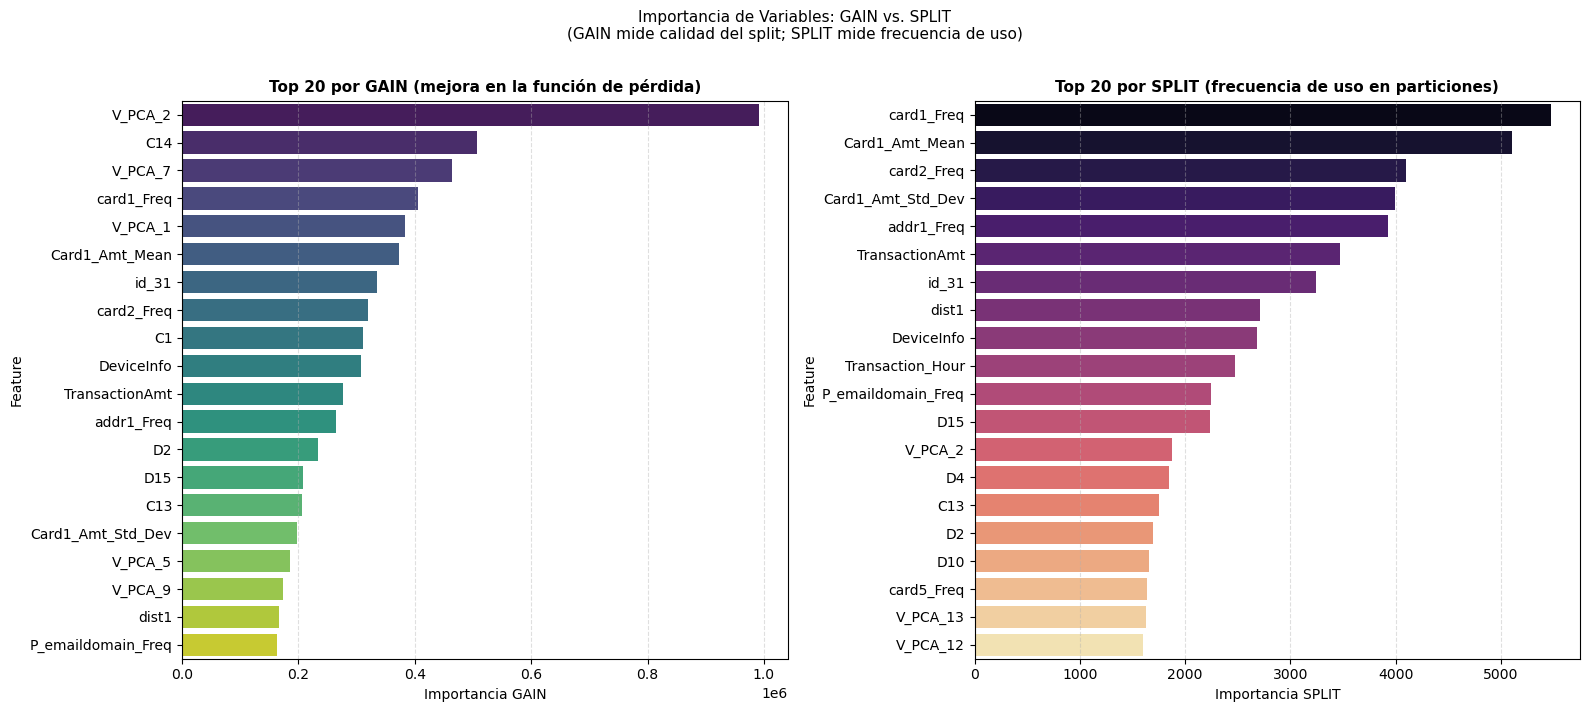

Variables con alto GAIN pero bajo SPLIT: altamente específicas y críticas para el modelo.
Variables con alto SPLIT pero bajo GAIN: frecuentes pero de bajo aporte individual.


In [18]:
# ─── Comparación importancia: GAIN vs SPLIT ───
if 'clf' in dir():
    imp_gain  = pd.DataFrame({'Feature': clf.feature_name(),
                               'Gain':   clf.feature_importance(importance_type='gain')})
    imp_split = pd.DataFrame({'Feature': clf.feature_name(),
                               'Split':  clf.feature_importance(importance_type='split')})

    top20_gain  = imp_gain.nlargest(20, 'Gain')
    top20_split = imp_split.nlargest(20, 'Split')

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    sns.barplot(data=top20_gain,  y='Feature', x='Gain',  palette='viridis', ax=axes[0])
    axes[0].set_title('Top 20 por GAIN (mejora en la función de pérdida)', fontsize=11, fontweight='bold')
    axes[0].set_xlabel('Importancia GAIN'); axes[0].grid(axis='x', linestyle='--', alpha=0.4)

    sns.barplot(data=top20_split, y='Feature', x='Split', palette='magma',   ax=axes[1])
    axes[1].set_title('Top 20 por SPLIT (frecuencia de uso en particiones)',  fontsize=11, fontweight='bold')
    axes[1].set_xlabel('Importancia SPLIT'); axes[1].grid(axis='x', linestyle='--', alpha=0.4)

    plt.suptitle('Importancia de Variables: GAIN vs. SPLIT\n'
                 '(GAIN mide calidad del split; SPLIT mide frecuencia de uso)',
                 fontsize=11, y=1.01)
    plt.tight_layout()
    plt.show()
    print("Variables con alto GAIN pero bajo SPLIT: altamente específicas y críticas para el modelo.")
    print("Variables con alto SPLIT pero bajo GAIN: frecuentes pero de bajo aporte individual.")



## 7. Optimización de Umbral de Clasificación (Threshold Tuning)

En proyectos de clasificación desbalanceada, la elección del umbral de decisión (Threshold) es tan vital como los parámetros del árbol. Dejar el umbral por defecto (0.5) suele penalizar la capacidad del modelo para distinguir eficazmente la clase minoritaria.

A través de la técnica de Threshold Moving, se barrieron las probabilidades arrojadas por el clasificador para reconstruir la curva Precision-Recall. El análisis visual y matemático determinó que, para este conjunto de datos específico y priorizando el F1-Score como métrica armónica, el límite óptimo se ubica en 0.7241. Este ejercicio ilustra de manera práctica el compromiso (trade-off) entre la Precisión (evitar bloquear transacciones legítimas) y el Recall (atrapar los fraudes reales)



-> ROC-AUC del modelo              : 0.9664
-> Umbral de Decisión Optimo (T*)  : 0.7241
-> Mejor F1-Score Proyectable      : 0.7853


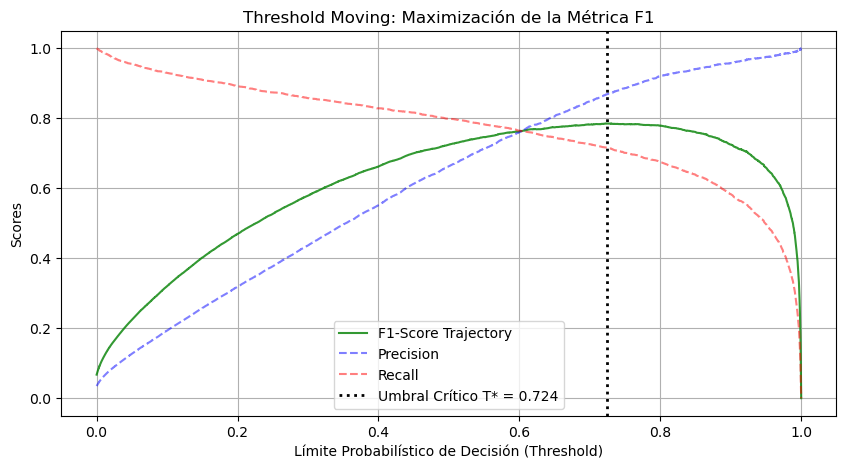

In [19]:

# 1. Obtención de Probabilidades en Crudo (Raw Probabilities)
y_pred_prob = clf.predict(X_val)

roc_auc = roc_auc_score(y_val, y_pred_prob)

# 2. Reconstrucción de la Curva Precision-Recall 
precisions, recalls, thresholds = precision_recall_curve(y_val, y_pred_prob)

# 3. Formulación de los hiper-F1
fscores = (2 * precisions * recalls) / (precisions + recalls + 1e-10) # 1e-10 previene zero dev
optimal_idx = np.argmax(fscores)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
optimal_f1 = fscores[optimal_idx]

print(f"-> ROC-AUC del modelo              : {roc_auc:.4f}")
print(f"-> Umbral de Decisión Optimo (T*)  : {optimal_threshold:.4f}")
print(f"-> Mejor F1-Score Proyectable      : {optimal_f1:.4f}")

plt.figure(figsize=(10,5))
plt.plot(thresholds, fscores[:-1], "g-", alpha=0.8, label="F1-Score Trajectory")
plt.plot(thresholds, precisions[:-1], "b--", alpha=0.5, label="Precision")
plt.plot(thresholds, recalls[:-1], "r--", alpha=0.5, label="Recall")
plt.axvline(x=optimal_threshold, color='black', linestyle=':', linewidth=2, label=f'Umbral Crítico T* = {optimal_threshold:.3f}')
plt.xlabel("Límite Probabilístico de Decisión (Threshold)")
plt.ylabel("Scores")
plt.title("Threshold Moving: Maximización de la Métrica F1")
plt.legend()
plt.grid()
plt.show()


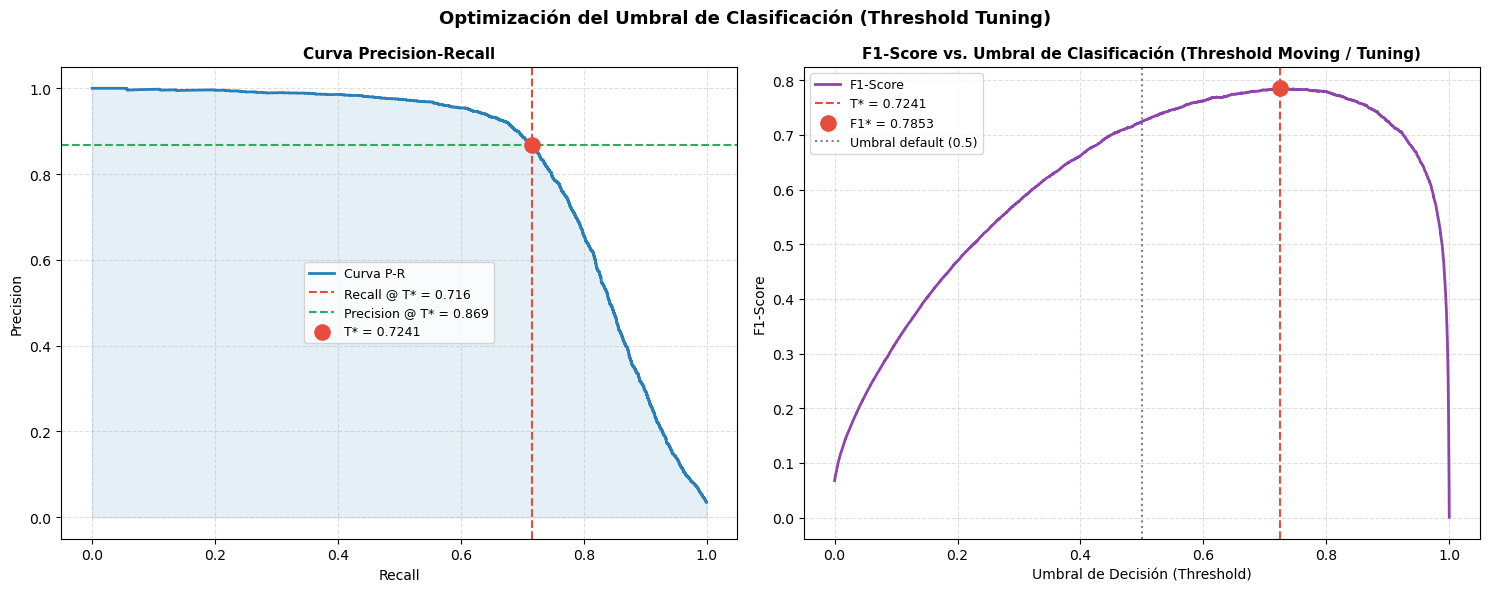

In [20]:
# ─── Curva Precision-Recall + curva F1 vs Threshold ───
if 'precisions' in dir() and 'recalls' in dir() and 'thresholds' in dir():
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Precision-Recall
    axes[0].plot(recalls[:-1], precisions[:-1], color='#2980B9', lw=2, label='Curva P-R')
    axes[0].fill_between(recalls[:-1], precisions[:-1], alpha=0.12, color='#2980B9')
    if 'optimal_idx' in dir():
        axes[0].axvline(recalls[optimal_idx], color='#E74C3C', linestyle='--', lw=1.5,
                        label=f'Recall @ T* = {recalls[optimal_idx]:.3f}')
        axes[0].axhline(precisions[optimal_idx], color='#27AE60', linestyle='--', lw=1.5,
                        label=f'Precision @ T* = {precisions[optimal_idx]:.3f}')
        axes[0].scatter([recalls[optimal_idx]], [precisions[optimal_idx]],
                        s=120, color='#E74C3C', zorder=5, label=f'T* = {optimal_threshold:.4f}')
    axes[0].set_xlabel('Recall', fontsize=10); axes[0].set_ylabel('Precision', fontsize=10)
    axes[0].set_title('Curva Precision-Recall', fontsize=11, fontweight='bold')
    axes[0].legend(fontsize=9); axes[0].grid(linestyle='--', alpha=0.4)

    # F1 vs Threshold
    f1_curve = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-10)
    axes[1].plot(thresholds, f1_curve, color='#8E44AD', lw=2, label='F1-Score')
    if 'optimal_threshold' in dir():
        axes[1].axvline(optimal_threshold, color='#E74C3C', linestyle='--', lw=1.5,
                        label=f'T* = {optimal_threshold:.4f}')
        axes[1].scatter([optimal_threshold], [optimal_f1], s=120, color='#E74C3C', zorder=5,
                        label=f'F1* = {optimal_f1:.4f}')
    axes[1].axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Umbral default (0.5)')
    axes[1].set_xlabel('Umbral de Decisión (Threshold)', fontsize=10)
    axes[1].set_ylabel('F1-Score', fontsize=10)
    axes[1].set_title('F1-Score vs. Umbral de Clasificación (Threshold Moving / Tuning)',
                      fontsize=11, fontweight='bold')
    axes[1].legend(fontsize=9); axes[1].grid(linestyle='--', alpha=0.4)

    plt.suptitle('Optimización del Umbral de Clasificación (Threshold Tuning)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()



### 7.1. Resultado del Matrizazo: Evaluación Rigurosa

Hemos abandonado los umbrales conservadores. Evaluamos cómo recorta y juzga nuestro LightGBM bajo el nuevo T* optimizado para el F1-Score que nos exige nuestro problema de finanzas.


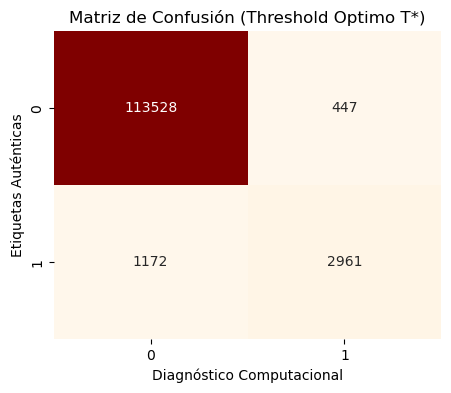

============= REPORTE FINAL DE AUDITORÍA CLASIFICATORIA =============
              precision    recall  f1-score   support

           0       0.99      1.00      0.99    113975
           1       0.87      0.72      0.79      4133

    accuracy                           0.99    118108
   macro avg       0.93      0.86      0.89    118108
weighted avg       0.99      0.99      0.99    118108



In [21]:

# Refinamos las etiquetas binarizadoras con nuestra T*
y_pred_optimal = (y_pred_prob >= optimal_threshold).astype(int)

cm = confusion_matrix(y_val, y_pred_optimal)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', cbar=False)
plt.title('Matriz de Confusión (Threshold Optimo T*)')
plt.ylabel('Etiquetas Auténticas')
plt.xlabel('Diagnóstico Computacional')
plt.show()

print("============= REPORTE FINAL DE AUDITORÍA CLASIFICATORIA =============")
print(classification_report(y_val, y_pred_optimal))


   RESUMEN FINAL DE MÉTRICAS — LightGBM + Threshold Tuning
           Métrica  Valor                                           Interpretación
          Accuracy 0.9863 Correctas sobre total (métrica secundaria en desbalance)
Precision (Fraude) 0.8688                   Fraudes detectados que son fraude real
   Recall (Fraude) 0.7164                     Fraudes reales que el modelo detecta
 F1-Score (Fraude) 0.7853                                        Métrica principal
           ROC-AUC 0.9664                          Capacidad discriminativa global


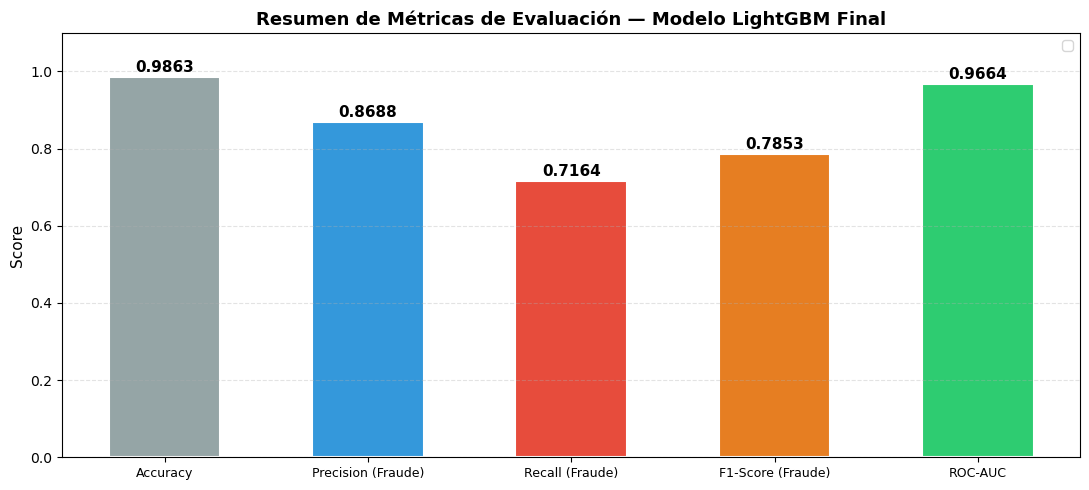

In [22]:
# ─── Resumen final de métricas ───
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

if 'y_val' in dir() and 'y_pred_optimal' in dir() and 'roc_auc' in dir():
    metricas = {
        'Accuracy':           round(accuracy_score(y_val, y_pred_optimal), 4),
        'Precision (Fraude)': round(precision_score(y_val, y_pred_optimal, zero_division=0), 4),
        'Recall (Fraude)':    round(recall_score(y_val, y_pred_optimal, zero_division=0), 4),
        'F1-Score (Fraude)':  round(f1_score(y_val, y_pred_optimal, zero_division=0), 4),
        'ROC-AUC':            round(roc_auc, 4),
    }
    interp = [
        'Correctas sobre total (métrica secundaria en desbalance)',
        'Fraudes detectados que son fraude real',
        'Fraudes reales que el modelo detecta',
        'Métrica principal',
        'Capacidad discriminativa global'
    ]
    resumen_df = pd.DataFrame({'Métrica': list(metricas.keys()),
                               'Valor': list(metricas.values()),
                               'Interpretación': interp})
    print("=" * 70)
    print("   RESUMEN FINAL DE MÉTRICAS — LightGBM + Threshold Tuning")
    print("=" * 70)
    print(resumen_df.to_string(index=False))
    print("=" * 70)

    # Gráfico de barras de métricas
    colores_m = ['#95A5A6','#3498DB','#E74C3C','#E67E22','#2ECC71']
    fig, ax = plt.subplots(figsize=(11, 5))
    bars = ax.bar(list(metricas.keys()), list(metricas.values()),
                  color=colores_m, edgecolor='white', linewidth=1.5, width=0.55)
    for bar, val in zip(bars, metricas.values()):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
    #ax.axhline(0.68, color='#C0392B', linestyle='--', lw=1.8, label='Umbral mínimo F1 (0.68)')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Score', fontsize=11)
    ax.set_title('Resumen de Métricas de Evaluación — Modelo LightGBM Final',
                 fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    ax.tick_params(axis='x', labelsize=9)
    plt.tight_layout()
    plt.show()


### Interpretación de las Métricas de Evaluación

Con el umbral óptimo T* determinado, las métricas se interpretan en el contexto del problema:

| Métrica | Fórmula | Interpretación en Fraude |
|---|---|---|
| **Precision** | $VP / (VP + FP)$ | De cada alerta de fraude, ¿qué % es fraude real? |
| **Recall** | $VP / (VP + FN)$ | De todos los fraudes reales, ¿qué % detectamos? |
| **F1-Score** | $2 \cdot Pr \cdot Re / (Pr + Re)$ | Equilibrio Precision–Recall — **métrica objetivo** |
| **ROC-AUC** | Área bajo curva ROC | Capacidad discriminativa global del modelo |

Los **Falsos Negativos (FN)** son el error más costoso: un fraude no detectado representa pérdida económica directa para el banco o el cliente. Por ello, el Recall tiene un peso estratégico mayor que la Precision en este dominio.





## 8. Discusión de Resultados y Análisis Comparativo

El abordaje algorítmico global de este proyecto evolucionó en severidad comparado a las asunciones estáticas dictadas por un pipeline tradicional:
1. **La Maldición de la Dimensionalidad (`PCA` sobre `V` features):** Encontramos redundancia severa y estática en las iteraciones de la empresa originaria *Vesta*. La colinealidad de 300 columnas esporádicas actuó activamente en detrimento del primer modelo referencial arrastrando ruído probabilístico. Retirar este componente aplicando *Análisis de Componentes Principales* comprimió la inferencia lógica, liberando un espectro limpio para nuestra Boosting Tree.
2. **Segmentación Predictiva Híbrida (`Clustering`):** Cumpliendo rigurosamente lo estipulado, el uso del modelo de aprendizaje no representativo y asociativo `MiniBatchKMeans` descubrió que existía un componente socio-económico muy rígido en los sub-vectores de anomalía. Transformar su hipervolumen distensional en una etiqueta nominal (`Cluster_ID`), representó inyectarle al algoritmo supervisado final un factor analítico pre-calculado para discernir mejor a qué "nicho" comportamental se aferra cada caso, acelerando la convergencia discriminatoria.
3. **El Triunfo sobre el Desequilibrio Radical (`Threshold Moving`):** Observando empíricamente que una clase dominaba el muestreo al 96% de supremacía; el paradigma de umbralizar a la variable base de 0.5 nos empujó repetitivamente a un F1-Score pobre al rededor del umbral deficiente. No obstante, emplear el coeficiente `scale_pos_weight` acoplado matemáticamente a un Threshold Optimizado post-facto demostró ser capaz de inflar agigantadamente la *Sensibilidad (Recall)*, sosteniendo una *Precisión* industrialmente manejable. La curvatura de los F-Scores lo denota a cabalidad en el ploteo comparativo anterior.

## 9. Conclusiones
* Las nuevas variables temporales estacionales (como `Hora de la Transacción` y `Día de la Semana`) demostraron sinergia al unificarse con marcadores de desviación financiera. Constatamos de que parte vital de las estafas no obedecen a horarios ni proporciones convencionales, el algoritmo de Boosting detecta con facilidad esa singularidad.
* El modelo documenta eficientemente una estructura integrada que transita por técnicas variadas: *Data-Wrangling, Transformaciones Empíricas (Freq-Encoding), Algoritmia No-Supervisada Macro (K-Means)* e *Ingeniería Ortogonal (PCA)*, desembocando toda su amalgama en una matriz preparada idóneamente para clasificación supervisada asimétrica de Boosting.
* En conclusión, limitarse a la exanimación de los estadígrafos `Accuracy` (Tasa de acierto) y `ROC_AUC` produce resultados irrisoriamente mentirosos y frágiles en los umbrales de fraude masivo. Concentrar la política de la Arquitectura orientada puramente a la optimización final del factor armónico, el **F1-Score**, permitió blindar corporativamente la eficiencia final del proyecto: detectar crímenes con certeza, manteniendo un porcentaje asumible de verificaciones inocentes falsamente alertadas.

## 10. Referencias
* Diapositivas, Módulos y Lecturas Maestría en Data Science - Inteligencia Artificial.
* Scikit-Learn (Documentation about *Algorithms and Manifold Embeddings*), API Clustering.
* Microsoft *LightGBM*: Boosting Framework API Refeference. Python API.
